In [3]:
%pip install seaborn pandas numpy matplotlib scikit-learn imbalanced-learn mlflow xgboost lightgbm fastapi uvicorn pydantic pytest requests

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached pyarrow-23.0.1-cp313-cp313-win_amd64.whl.metadata (3.1 kB)
  Using cached starlette-0.52.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cac


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\chara\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [6]:
data_path = "../data/creditcard.csv"

In [7]:
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset not found at {data_path}. Please download it from Kaggle.")

df = pd.read_csv(data_path)
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset Shape: 284807 rows, 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
print("--- Missing Values Per Column ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if any(missing_values > 0) else "No null values found!")

print("\n--- Data Type Summary ---")
print(df.dtypes.value_counts())

--- Missing Values Per Column ---
No null values found!

--- Data Type Summary ---
float64    30
int64       1
Name: count, dtype: int64


In [9]:
class_counts = df['Class'].value_counts()
class_pcts = df['Class'].value_counts(normalize=True) * 100

print(f"Non-Fraudulent (Class 0): {class_counts[0]} ({class_pcts[0]:.3f}%)")
print(f"Fraudulent (Class 1):     {class_counts[1]} ({class_pcts[1]:.3f}%)")

Non-Fraudulent (Class 0): 284315 (99.827%)
Fraudulent (Class 1):     492 (0.173%)


C:\Users\chara\AppData\Local\Temp\ipykernel_14256\4206273880.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='Set1')


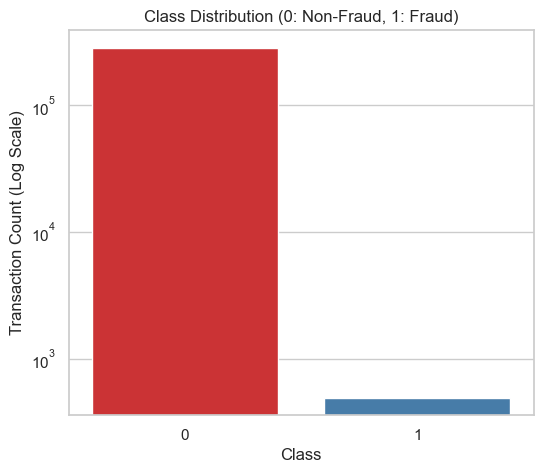

In [10]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Class', data=df, palette='Set1')
plt.title('Class Distribution (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Transaction Count (Log Scale)')
plt.yscale('log')  # Applying log scale because of severe imbalance
plt.xlabel('Class')
plt.show()

In [11]:
corr_matrix = df.corr()

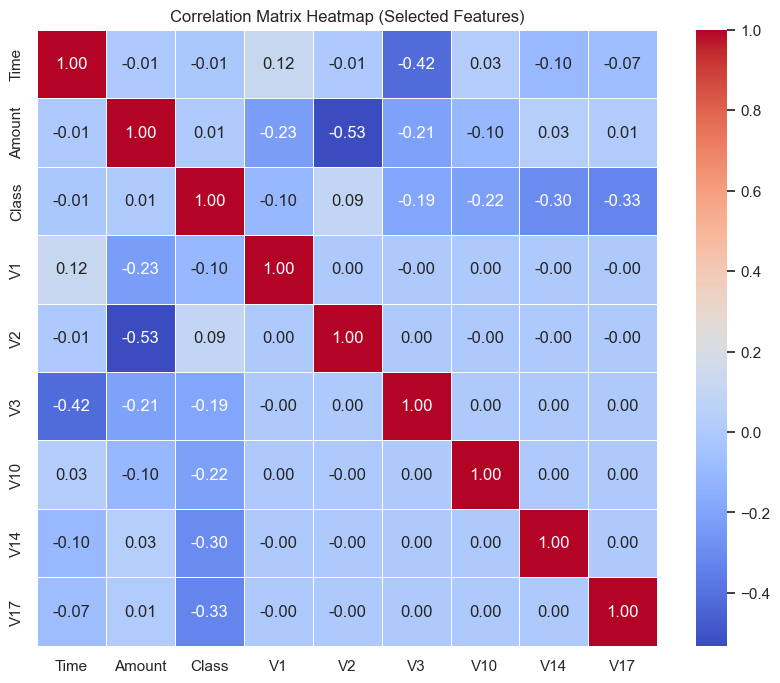

In [12]:
features_to_plot = ['Time', 'Amount', 'Class', 'V1', 'V2', 'V3', 'V10', 'V14', 'V17']
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix.loc[features_to_plot, features_to_plot], annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap (Selected Features)')
plt.show()

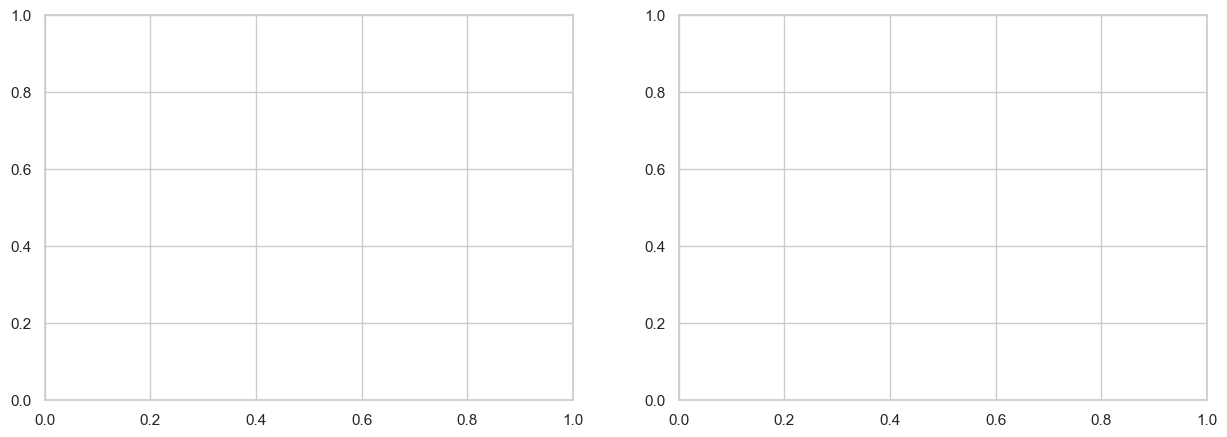

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

In [14]:
sns.histplot(df[df['Class'] == 1]['Amount'], ax=ax[0], color='red', label='Fraud', kde=True, stat="density", common_norm=False)
sns.histplot(df[df['Class'] == 0]['Amount'], ax=ax[0], color='blue', label='Normal', kde=True, stat="density", common_norm=False)
ax[0].set_title('Distribution of Transaction Amounts (Density)')
ax[0].set_xlim([0, 2000])  # Cap X-axis to see the bulk of the data
ax[0].legend()

In [15]:
sns.histplot(df[df['Class'] == 1]['Time'], ax=ax[1], color='red', label='Fraud', kde=True, stat="density", common_norm=False)
sns.histplot(df[df['Class'] == 0]['Time'], ax=ax[1], color='blue', label='Normal', kde=True, stat="density", common_norm=False)
ax[1].set_title('Distribution of Transaction Time (Density)')
ax[1].legend()

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>